In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

resumes = pd.read_csv("../data/processed/resumes_clean.csv")
resumes = resumes.dropna(subset=["clean_text", "Category"])

print("Total resumes:", resumes.shape)
print("Categories:", resumes["Category"].nunique())

X = resumes["clean_text"]
y = resumes["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Total resumes: (2460, 3)
Categories: 25

Train size: 1968
Test size: 492


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Convert text to numeric vectors
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

# Train classifier
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_tfidf, y_train)

print("\nModel trained.")

TF-IDF train shape: (1968, 5000)
TF-IDF test shape: (492, 5000)

Model trained.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = clf.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6809

Classification Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.80      0.83      0.82        24
              ADVOCATE       0.50      0.62      0.56        24
           AGRICULTURE       1.00      0.23      0.38        13
               APPAREL       0.82      0.47      0.60        19
                  ARTS       0.64      0.43      0.51        21
              AVIATION       0.73      0.70      0.71        23
               BANKING       0.76      0.83      0.79        23
  BUSINESS-DEVELOPMENT       0.44      0.71      0.54        24
                  CHEF       0.95      0.75      0.84        24
          CONSTRUCTION       0.82      0.82      0.82        22
            CONSULTANT       0.67      0.35      0.46        23
              DESIGNER       0.75      0.71      0.73        21
         DIGITAL-MEDIA       0.71      0.53      0.61        19
       DevOps Engineer       0.00      0.00      0.00         

C:\Users\pujal\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pujal\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pujal\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [ ]:
print("All categories after reload:")
print(resumes["Category"].value_counts())

All categories after reload:
Category
HR                        120
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      119
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
FINANCE                   117
SALES                     116
AVIATION                  116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
Java Developer             13
DevOps Engineer             7
Testing                     7
Name: count, dtype: int64


In [ ]:
# Drop inconsistent/low-sample categories
bad_categories = ["Java Developer", "DevOps Engineer", "Testing"]
resumes_filtered = resumes[~resumes["Category"].isin(bad_categories)].reset_index(drop=True)

print("Before filtering:", resumes.shape)
print("After filtering:", resumes_filtered.shape)
print("Remaining categories:", resumes_filtered["Category"].nunique())

# Redo the split, vectorization, and training on filtered data
X = resumes_filtered["clean_text"]
y = resumes_filtered["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_tfidf, y_train)

y_pred = clf.predict(X_test_tfidf)
print("\nNew accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\n", classification_report(y_test, y_pred))

Before filtering: (2460, 3)
After filtering: (2433, 3)
Remaining categories: 22

New accuracy: 0.6571

                         precision    recall  f1-score   support

            ACCOUNTANT       0.80      0.83      0.82        24
              ADVOCATE       0.47      0.58      0.52        24
           AGRICULTURE       1.00      0.46      0.63        13
               APPAREL       0.62      0.26      0.37        19
                  ARTS       0.60      0.29      0.39        21
              AVIATION       0.71      0.65      0.68        23
               BANKING       0.78      0.78      0.78        23
  BUSINESS-DEVELOPMENT       0.37      0.67      0.48        24
                  CHEF       0.95      0.75      0.84        24
          CONSTRUCTION       0.82      0.82      0.82        22
            CONSULTANT       0.64      0.30      0.41        23
              DESIGNER       0.79      0.71      0.75        21
         DIGITAL-MEDIA       0.77      0.53      0.62        19

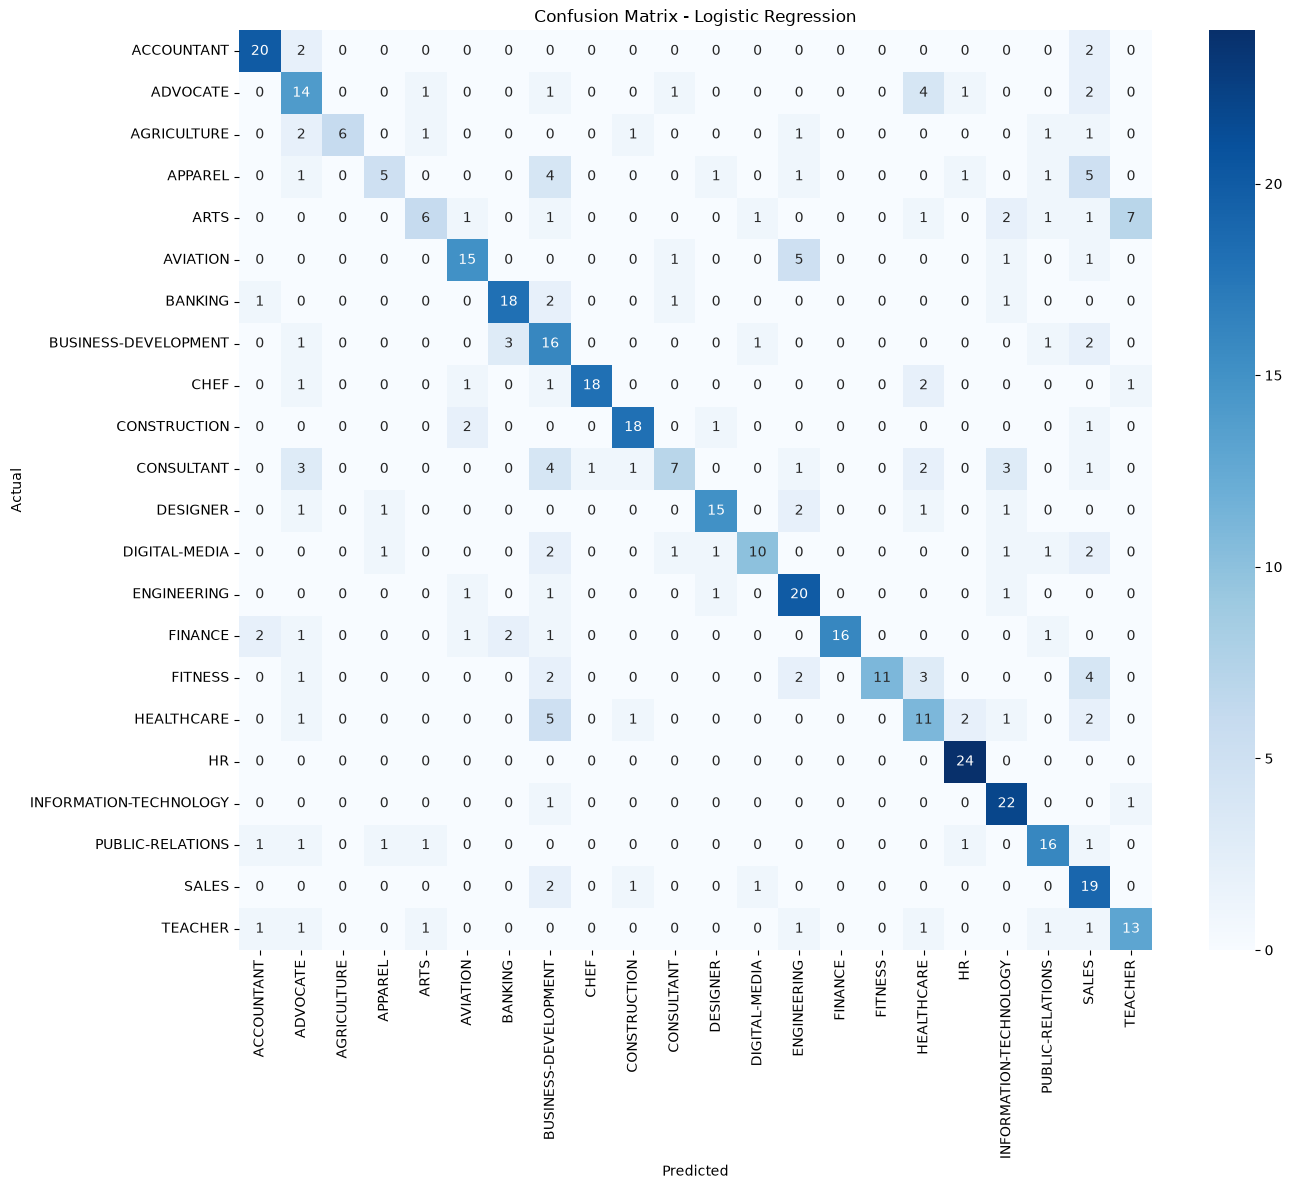

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/confusion_matrix_logreg.png", dpi=150)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_tfidf, y_train)

y_pred_rf = rf_clf.predict(X_test_tfidf)

print("Random Forest Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("\nLogistic Regression Accuracy:", round(accuracy_score(y_test, y_pred), 4))

Random Forest Accuracy: 0.7002

Logistic Regression Accuracy: 0.6571


In [ ]:
import pickle

with open("../models/classifier.pkl", "wb") as f:
    pickle.dump(rf_clf, f)

with open("../models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Saved classifier.pkl and tfidf_vectorizer.pkl to /models")

Saved classifier.pkl and tfidf_vectorizer.pkl to /models


In [ ]:
from sklearn.metrics import roc_auc_score

# Get predicted probabilities (needed for ROC-AUC, not just hard predictions)
y_proba_rf = rf_clf.predict_proba(X_test_tfidf)

roc_auc = roc_auc_score(
    y_test, y_proba_rf, multi_class="ovr", average="macro", labels=rf_clf.classes_
)
print("Random Forest ROC-AUC (macro, one-vs-rest):", round(roc_auc, 4))

Random Forest ROC-AUC (macro, one-vs-rest): 0.9689
